# Actividad guiada con pistas: K-Means con el dataset **NYPD Arrest Data**

## Objetivos
1. Explorar el dataset.
2. Seleccionar variables adecuadas para K-Means.
3. Preparar los datos.
4. Escalar las variables.
5. Probar varios valores de `k`.
6. Interpretar los clusters obtenidos.

> Usa las pistas solo si te bloqueas. La idea es que el notebook te ayude, pero que el razonamiento lo hagas tú.


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


df = pd.read_csv("NYPD_Arrest_Data__Year_to_Date_.csv")

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (278953, 19)


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 1. Exploración inicial

### Tarea
Muestra:
- las columnas del dataset,
- los tipos de datos,
- y los valores nulos.

### Responde
- ¿Qué variables parecen útiles para K-Means?
- ¿Qué variables no se pueden usar directamente?


In [88]:
# PISTA:
# - Usa df.columns para ver las columnas
# - Usa df.dtypes para ver los tipos de datos
# - Usa df.isna().sum() para ver los valores nulos
# - Si quieres ordenar los nulos: sort_values(ascending=False)

# Escribe aquí tu código

print("Columnas: " + str(df.columns))
print("Valores nulos: " + str(df.isna().sum())) 
df.info()


Columnas: Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')
Valores nulos: ARREST_KEY              0
ARREST_DATE             0
PD_CD                   0
PD_DESC                 0
KY_CD                  23
OFNS_DESC               0
LAW_CODE                0
LAW_CAT_CD           1474
ARREST_BORO             0
ARREST_PRECINCT         0
JURISDICTION_CODE       0
AGE_GROUP               0
PERP_SEX                0
PERP_RACE               0
X_COORD_CD              0
Y_COORD_CD              0
Latitude                0
Longitude               0
Location                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
--

In [89]:
df["AGE_GROUP"].value_counts()

AGE_GROUP
(null)    147237
25-44      77063
45-64      29326
18-24      17786
<18         4766
65+         2775
Name: count, dtype: int64

## 2. Crear una variable numérica para la edad

La columna `AGE_GROUP` es categórica.  
Transforma sus categorías en valores numéricos aproximados.

Sugerencia:
- `<18` → 17
- `18-24` → 21
- `25-44` → 34.5
- `45-64` → 54.5
- `65+` → 70


In [90]:
# PISTA:
# 1) Crea un diccionario de equivalencias
# 2) Usa df["AGE_GROUP"].map(...)
# 3) Guarda el resultado en una nueva columna llamada AGE_NUM
# 4) Si aparecen NaN, revisa si falta alguna categoría en el diccionario

df["AGE_NUM"] = df["AGE_GROUP"].map({
    "<18": 17,
    "18-24": 21,
    "25-44": 34.5,
    "45-64": 54.5,
    "65+": 70
})

df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location,AGE_NUM
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543),34.5
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005),34.5
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823),34.5
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),NaN
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259),34.5


## 3. Selección de variables

### Tarea
Crea un nuevo DataFrame con estas variables:
- `Latitude`
- `Longitude`
- `ARREST_PRECINCT`
- `JURISDICTION_CODE`
- `AGE_NUM`

Después elimina los valores nulos.


In [101]:
# PISTA:
# - Crea una lista con los nombres de las columnas
# - Usa df[lista_columnas] para seleccionar
# - Usa dropna() para eliminar filas con nulos
# - Comprueba el tamaño antes y después

# Escribe aquí tu código
df_cluster = df[["AGE_NUM", "ARREST_PRECINCT","Latitude","Longitude","JURISDICTION_CODE"]].dropna()


In [102]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131716 entries, 0 to 278951
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   AGE_NUM            131716 non-null  float64
 1   ARREST_PRECINCT    131716 non-null  int64  
 2   Latitude           131716 non-null  float64
 3   Longitude          131716 non-null  float64
 4   JURISDICTION_CODE  131716 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 6.0 MB


## 4. Crear una muestra

El dataset es grande.  
Toma una muestra aleatoria de hasta **15.000 filas** para trabajar más rápido.


In [103]:
# PISTA:
# - Usa .sample()
# - Añade random_state=42 para que siempre salga la misma muestra
# - Puedes hacer algo así:
#   muestra = datos.sample(n=15000, random_state=42)
# - Pero antes conviene comprobar si hay al menos 15000 filas

# Escribe aquí tu código
df_cluster_sample = df_cluster.sample(n=15000, random_state=42)
print("Tamaño del cluster original: " + str(df_cluster.shape))
print("Tamaño del cluster de muestra: " + str(df_cluster_sample.shape))


Tamaño del cluster original: (131716, 5)
Tamaño del cluster de muestra: (15000, 5)


## 5. Escalado

### Tarea
Escala la muestra con `StandardScaler` y guarda el resultado en `X`.

### Responde
- ¿Por qué es necesario escalar antes de aplicar K-Means?
- Porque el rango de las distancias afecta a la agrupación de los clusters


In [104]:
# PISTA:
# - Crea un objeto StandardScaler()
# - Usa fit_transform() sobre la muestra
# - Guarda el resultado en X
# - K-Means usa distancias, por eso el escalado es importante

# Escribe aquí tu código
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster_sample)



## 6. Método del codo y silhouette

### Tarea
Prueba valores de `k` entre 2 y 8.
Para cada uno:
- ajusta un modelo K-Means,
- guarda la inercia,
- calcula el `silhouette_score`.

Después representa ambas métricas en dos gráficas.


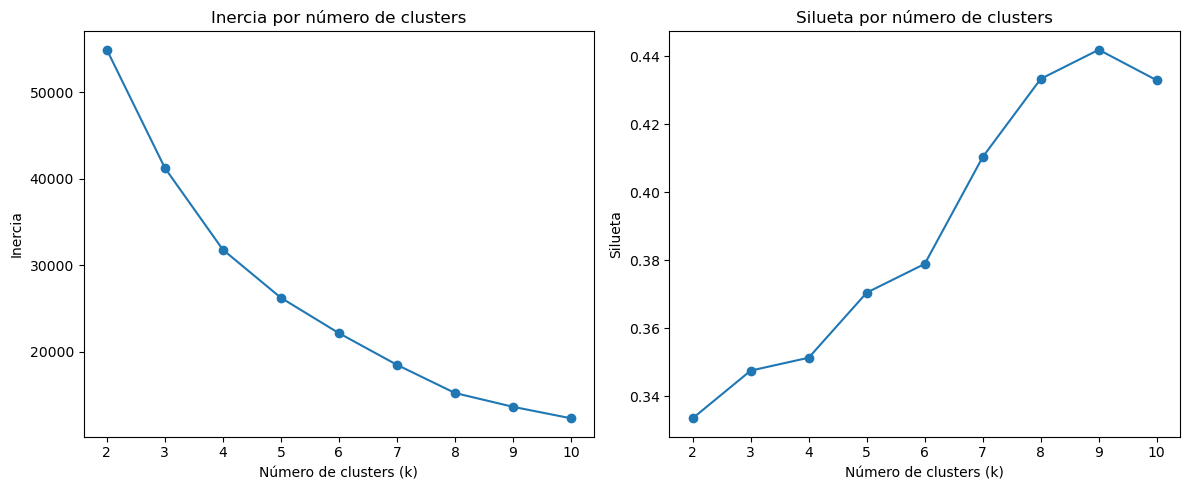

In [105]:
# PISTA:
# - Crea listas vacías: inercias = [] y siluetas = []
# - Recorre varios valores de k con un for
# - En cada vuelta:
#       modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
#       etiquetas = modelo.fit_predict(X)
#       inercias.append(modelo.inertia_)
#       siluetas.append(silhouette_score(X, etiquetas))
# - Después representa ambas listas con plt.plot(...)

# Escribe aquí tu código
inercias = []
siluetas = []
for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X, etiquetas))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inercias, marker='o')
plt.title('Inercia por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), siluetas, marker='o')
plt.title('Silueta por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silueta')
plt.tight_layout()
plt.show()


## 7. Elección de `k`

### Responde
- ¿Qué valor de `k` te parece más razonable?
- ¿Coinciden el método del codo y la silueta?
- ¿La elección es completamente objetiva?

**Pista conceptual:**  
Busca un equilibrio entre:
- un “codo” visible en la gráfica de inercia,
- y un valor alto de `silhouette_score`.


In [106]:
# Escribe aquí, si quieres, el valor elegido
k_final = 5


## 8. Entrenamiento del modelo final

### Tarea
Entrena el modelo con `k_final` y añade la columna `cluster` al DataFrame de trabajo.


In [107]:
# PISTA:
# - Crea el modelo KMeans con k_final
# - Usa fit_predict(X)
# - Guarda las etiquetas en una variable, por ejemplo: clusters
# - Haz una copia de la muestra y añade una nueva columna llamada cluster

# Escribe aquí tu código
modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10, max_iter=300)
clusters = modelo_final.fit_predict(X)
df_cluster_sample["cluster"] = clusters
df_cluster_sample.head()


,AGE_NUM,ARREST_PRECINCT,Latitude,Longitude,JURISDICTION_CODE,cluster
215925,34.5,34,40.862605,-73.920276,0,3
49437,34.5,75,40.671413,-73.881510,0,1
224194,34.5,114,40.788556,-73.884443,0,1
211066,34.5,49,40.855802,-73.843910,0,3
229712,34.5,77,40.674601,-73.930573,0,0


## 9. Visualización de clusters

Representa los clusters con:
- `Longitude` en el eje X
- `Latitude` en el eje Y


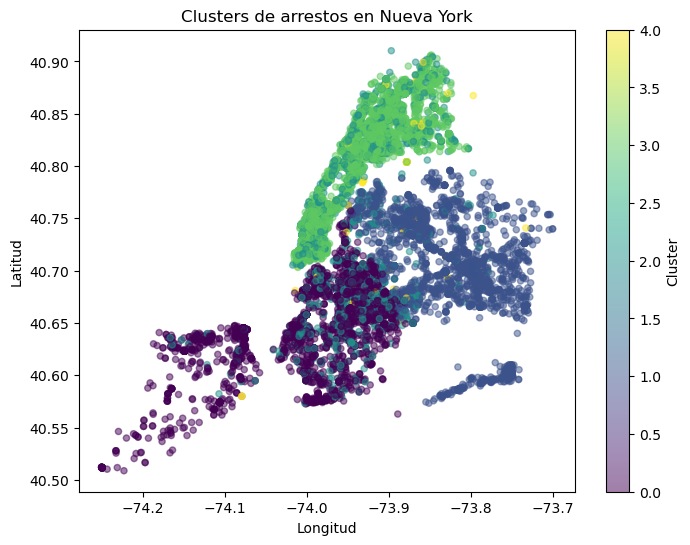

In [111]:
# PISTA:
# - Usa plt.figure(...)
# - Usa plt.scatter(...)
# - En c=... debes indicar la columna de clusters
# - Etiqueta los ejes y añade título

# Ejemplo de idea:
# plt.scatter(resultado["Longitude"], resultado["Latitude"], c=resultado["cluster"])

# Escribe aquí tu código
plt.figure(figsize=(8, 6))
plt.scatter(df_cluster_sample["Longitude"], df_cluster_sample["Latitude"], c=df_cluster_sample["cluster"], cmap='viridis', alpha=0.5, s=20)
plt.title('Clusters de arrestos en Nueva York')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.colorbar(label='Cluster')
plt.show()


## 10. Centroides en escala original

### Tarea
- Obtén los centroides del modelo.
- Transfórmalos de nuevo a la escala original.
- Muéstralos en un DataFrame.


In [109]:
# PISTA:
# - Los centroides del modelo están en kmeans.cluster_centers_
# - Están escalados, así que hay que usar scaler.inverse_transform(...)
# - Después puedes convertir el resultado en DataFrame con las columnas originales

# Escribe aquí tu código
centroides_escalados = modelo_final.cluster_centers_
centroides = scaler.inverse_transform(centroides_escalados)
df_centroides = pd.DataFrame(centroides, columns=df_cluster_sample.columns[:-1])
df_centroides 


,AGE_NUM,ARREST_PRECINCT,Latitude,Longitude,JURISDICTION_CODE
0,32.749933,85.051701,40.648140,-73.993127,0.322261
1,35.740683,105.937371,40.709820,-73.829266,0.551501
2,56.157233,50.229005,40.743581,-73.944337,0.321865
3,31.187665,30.328634,40.803761,-73.934363,0.279075
4,38.106250,50.543750,40.756161,-73.915822,76.543750


## 11. Interpretación final

### Responde brevemente
1. ¿Qué patrón general observas en los clusters?
2. ¿Qué variables parecen influir más?
3. ¿Qué limitaciones tiene K-Means en este dataset?
4. ¿Qué otro algoritmo podría funcionar mejor y por qué?

**Pistas de reflexión:**
- ¿Los grupos parecen zonas geográficas?
- ¿K-Means funciona bien con distribuciones irregulares?
- ¿Qué ocurre con las variables categóricas?
- ¿Te parecería mejor DBSCAN para datos espaciales?


In [110]:
# Puedes escribir aquí tus conclusiones en comentarios
# o crear una celda Markdown nueva debajo.
